In [4]:
import os
from collections import OrderedDict
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import json
import reprlib
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np

In [5]:
df = pd.read_csv('../preprocessing/cleaned_text.csv')
df.head()

,full_text,case_folding,tokens,normalized,stopword_removal,stemming
0,Chale Your man start dey do Crypto Football ay...,chale your man start dey do crypto football ay...,"['chale', 'your', 'man', 'start', 'dey', 'do',...","['chale', 'your', 'man', 'start', 'dey', 'di',...","['chale', 'man', 'start', 'dey', 'crypto', 'fo...","['chale', 'man', 'start', 'dey', 'crypto', 'fo..."
1,Bitcoin Orange OGsatoshis,bitcoin orange ogsatoshis,"['bitcoin', 'orange', 'ogsatoshis']","['bitcoin', 'orange', 'ogsatoshis']","['bitcoin', 'orange', 'ogsatoshis']","['bitcoin', 'orange', 'ogsatoshis']"
2,WahyuS Problem terbesar yg diselesaikan web ad...,wahyus problem terbesar yg diselesaikan web ad...,"['wahyus', 'problem', 'terbesar', 'yg', 'disel...","['wahyus', 'problem', 'terbesar', 'yang', 'dis...","['wahyus', 'problem', 'terbesar', 'diselesaika...","['wahyus', 'problem', 'besar', 'selesai', 'web..."
3,Buat ngejelasin ke boomer yang bilang Underwea...,buat ngejelasin ke boomer yang bilang underwea...,"['buat', 'ngejelasin', 'ke', 'boomer', 'yang',...","['buat', 'menjelaskan', 'ke', 'boomer', 'yang'...","['boomer', 'bilang', 'underwear', 'eh', 'under...","['boomer', 'bilang', 'underwear', 'eh', 'under..."
4,Ek aisi wife to main bhi deserve karta hu yaar,ek aisi wife to main bhi deserve karta hu yaar,"['ek', 'aisi', 'wife', 'to', 'main', 'bhi', 'd...","['ek', 'aisi', 'wife', 'tapi', 'main', 'bhi', ...","['ek', 'aisi', 'wife', 'main', 'bhi', 'deserve...","['ek', 'aisi', 'wife', 'main', 'bhi', 'deserve..."


In [6]:
df.drop(['full_text', 'case_folding', 'tokens', 'normalized', 'stopword_removal'], axis=1, inplace=True)
df.head()

,stemming
0,"['chale', 'man', 'start', 'dey', 'crypto', 'fo..."
1,"['bitcoin', 'orange', 'ogsatoshis']"
2,"['wahyus', 'problem', 'besar', 'selesai', 'web..."
3,"['boomer', 'bilang', 'underwear', 'eh', 'under..."
4,"['ek', 'aisi', 'wife', 'main', 'bhi', 'deserve..."


In [7]:
#Mengubah bentuk dataframe menjadi string(kalimat utuh)
df['stemming'] = [' '.join(eval(str)) for str in df['stemming'].values]
df

,stemming
0,chale man start dey crypto football ay kak aa ...
1,bitcoin orange ogsatoshis
2,wahyus problem besar selesai web risiko orang ...
3,boomer bilang underwear eh underlyingnya bitcoin
4,ek aisi wife main bhi deserve karta hu yaar
...,...
1231,raja mata uang crypto bitcoin postingan halama...
1232,ktk kampuni zenye market cap kubwa duniani ora...
1233,meinmokhtar hang keje penuh asb dah n asbn bal...
1234,join gabung ajar santuy bareng cryptorize mala...


In [8]:
# Memanfaatkan nltk VADER untuk menggunakan leksikon kustom

sia1A, sia1B, sia2= SentimentIntensityAnalyzer(), SentimentIntensityAnalyzer(), SentimentIntensityAnalyzer()
# membersihkan leksikon VADER default
sia1A.lexicon.clear()
sia1B.lexicon.clear()
sia2.lexicon.clear()

# Membaca leksikon InSet
# Leksikon InSet lexicon dibagi menjadi dua, yakni polaritas negatif dan polaritas positif;
# kita akan menggunakan nilai compound saja untuk memberi label pada suatu kalimat
with open('../../InSet/_json_inset-neg.txt') as f:
    data1A = f.read()
with open('../../InSet/_json_inset-pos.txt') as f:
    data1B = f.read()

#Gabungkan leksikon InSet negatif dan positif menjadi satu

# Membaca leksikon SentiWords ID
with open('../../sentistrength_id/_json_sentiwords_id.txt') as f:
    data2 = f.read()


# Memasukkan data leksikon InSet dan SentiStrengthID ke dalam VADER kustom
inset_neg = json.loads(data1A)
inset_pos = json.loads(data1B)
sentis = json.loads(data2)


sia1A.lexicon.update(inset_neg)
sia1B.lexicon.update(inset_pos)
sia2.lexicon.update(sentis)

print(reprlib.repr(sia1A.lexicon))
print(reprlib.repr(sia1B.lexicon))
print(reprlib.repr(sia2.lexicon))
print("Leksikon InSet Negatif:", len(sia1A.lexicon))
print("Leksikon InSet Positif:", len(sia1B.lexicon))
print("Leksikon SentiWords ID :", len(sia2.lexicon))

{'(barang) bekas': -4, '(olahraga) bokser': -5, '(tua) uzur': -3, 'Anda': -4, ...}
{'(hujan) gerimis': 1, '(warna) dadu': 3, 'Ahad': 3, 'Sri paduka': 4, ...}
{'abadi': 5, 'absen': -3, 'abu-abu': -1, 'acuh': 4, ...}
Leksikon InSet Negatif: 6607
Leksikon InSet Positif: 3609
Leksikon SentiWords ID : 1729


In [9]:
sample = "bitcoin btc alami turun signifikan februari kisar harga stabil kali november btc turun turun rebound simak analisis lengkap"
print("Sample Text:", sample)
print("InSet Negatif Scores:", sia1A.polarity_scores(sample))
print("InSet Positif Scores:", sia1B.polarity_scores(sample))
if (sia1B.polarity_scores(sample)['compound'] + sia1A.polarity_scores(sample)['compound'] > 0):
    print("InSet Overall Sentiment: Positive")
else:
    print("InSet Overall Sentiment: Negative")

print("SentiWords ID Scores:", sia2.polarity_scores(sample))
if (sia2.polarity_scores(sample)['compound'] >= 0):
    print("SentiWords ID Overall Sentiment: Positive")
else:
    print("SentiWords ID Overall Sentiment: Negative")


Sample Text: bitcoin btc alami turun signifikan februari kisar harga stabil kali november btc turun turun rebound simak analisis lengkap
InSet Negatif Scores: {'neg': 0.684, 'neu': 0.316, 'pos': 0.0, 'compound': -0.9818}
InSet Positif Scores: {'neg': 0.0, 'neu': 0.278, 'pos': 0.722, 'compound': 0.9776}
InSet Overall Sentiment: Negative
SentiWords ID Scores: {'neg': 0.441, 'neu': 0.412, 'pos': 0.147, 'compound': -0.9001}
SentiWords ID Overall Sentiment: Negative


In [10]:
def is_positive_inset(tweet: str) -> bool:
    """True if tweet has positive compound sentiment, False otherwise."""
    return sia1A.polarity_scores(tweet)["compound"] + sia1B.polarity_scores(tweet)["compound"] > 0

def is_positive_senti(tweet: str) -> bool:
    """True if tweet has positive compound sentiment, False otherwise."""
    return sia2.polarity_scores(tweet)["compound"] > 0

In [11]:
tweets = df["stemming"]

# Menulis hasil klasifikasi label untuk setiap kalimat berdasarkan nilai compound dari insetNeg dan insetPos

for tweet in tweets:
    if is_positive_inset(tweet) == True:
        label = "pos"
    else:
        label = "neg"
    df.loc[df['stemming'] == tweet, 'inset'] = label

# Menulis hasil klasifikasi label untuk setiap kalimat berdasarkan nilai compound dari SentiStrength
for tweet in tweets:
    if is_positive_senti(tweet) == True:
        label = "pos"
    else:
        label = "neg"
    df.loc[df['stemming'] == tweet, 'senti'] = label
    
df

,stemming,inset,senti
0,chale man start dey crypto football ay kak aa ...,neg,neg
1,bitcoin orange ogsatoshis,neg,neg
2,wahyus problem besar selesai web risiko orang ...,neg,pos
3,boomer bilang underwear eh underlyingnya bitcoin,neg,neg
4,ek aisi wife main bhi deserve karta hu yaar,neg,neg
...,...,...,...
1231,raja mata uang crypto bitcoin postingan halama...,neg,neg
1232,ktk kampuni zenye market cap kubwa duniani ora...,pos,neg
1233,meinmokhtar hang keje penuh asb dah n asbn bal...,neg,pos
1234,join gabung ajar santuy bareng cryptorize mala...,neg,pos


In [12]:
pos1 = df['inset'].str.count('pos').sum()
print(f'Jumlah label positif InSet: {pos1}')
neg1 = df['inset'].str.count('neg').sum()
print(f'Jumlah label negatif InSet: {neg1}')

pos2 = df['senti'].str.count('pos').sum()
print(f'Jumlah label positif SentiStrengthID: {pos2}')
neg2 = df['senti'].str.count('neg').sum()
print(f'Jumlah label negatif SentiStrengthID: {neg2}')

'''pos3 = df['ensemble'].str.count('pos').sum()
print(f'Jumlah label positif Ensemble: {pos3}')
neg3 = df['ensemble'].str.count('neg').sum()
print(f'Jumlah label negatif Ensemble: {neg3}')'''

Jumlah label positif InSet: 400
Jumlah label negatif InSet: 836
Jumlah label positif SentiStrengthID: 273
Jumlah label negatif SentiStrengthID: 963


"pos3 = df['ensemble'].str.count('pos').sum()\nprint(f'Jumlah label positif Ensemble: {pos3}')\nneg3 = df['ensemble'].str.count('neg').sum()\nprint(f'Jumlah label negatif Ensemble: {neg3}')"

In [13]:
#df.to_csv('data_labeled.csv', index=False)

In [14]:
"""txt_positive_inset = ' '.join(df[df['inset'] == 'pos']['stemming'].astype(str))
txt_negative_inset = ' '.join(df[df['inset'] == 'neg']['stemming'].astype(str))
txt_positive_senti = ' '.join(df[df['senti'] == 'pos']['stemming'].astype(str))
txt_negative_senti = ' '.join(df[df['senti'] == 'neg']['stemming'].astype(str))

wordcloud_inset_pos = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=200,
    max_font_size=100,
).generate(txt_positive_inset)"""

"txt_positive_inset = ' '.join(df[df['inset'] == 'pos']['stemming'].astype(str))\ntxt_negative_inset = ' '.join(df[df['inset'] == 'neg']['stemming'].astype(str))\ntxt_positive_senti = ' '.join(df[df['senti'] == 'pos']['stemming'].astype(str))\ntxt_negative_senti = ' '.join(df[df['senti'] == 'neg']['stemming'].astype(str))\n\nwordcloud_inset_pos = WordCloud(\n    width=800,\n    height=400,\n    background_color='white',\n    max_words=200,\n    max_font_size=100,\n).generate(txt_positive_inset)"

In [15]:
'''plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_inset_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - InSet Positif', fontsize=16)
plt.show()'''

"plt.figure(figsize=(10, 5))\nplt.imshow(wordcloud_inset_pos, interpolation='bilinear')\nplt.axis('off')\nplt.title('Word Cloud - InSet Positif', fontsize=16)\nplt.show()"

In [ ]:
# Chart untuk distribusi label InSet
labels_inset = ['Positive', 'Negative']
sizes_inset = [pos1, neg1]
plt.figure(figsize=(6, 6))
plt.pie(sizes_inset, labels=labels_inset, autopct='%1.2f%%', startangle=140)
plt.text(-1.2, -1.2, f'Jumlah Data Label Positif: {pos1}\nJumlah Data Label Negatif: {neg1}', ha='left', fontsize=10)
plt.title('Distribusi Label InSet')

# Chart untuk distribusi label SentiStrengthID
labels_senti = ['Positive', 'Negative']
sizes_senti = [pos2, neg2]
plt.figure(figsize=(6, 6))
plt.pie(sizes_senti, labels=labels_senti, autopct='%1.2f%%', startangle=140)
plt.text(-1.2, -1.2, f'Jumlah Data Label Positif: {pos2}\nJumlah Data Label Negatif: {neg2}', ha='left', fontsize=10)
plt.title('Distribusi Label SentiStrengthID')
plt.show()


In [22]:
# Kappa Score
from sklearn.metrics import cohen_kappa_score

y1 = df['inset']
y2 = df['senti']

label_mapping = {'positive': 1, 'negative': -1}

kappa_score = cohen_kappa_score(y1, y2, labels=['pos', 'neg'])
print(f"Cohen's Kappa Score: {kappa_score:.4f}")

kappa_score = cohen_kappa_score(y1, y2, labels=['pos', 'neg'], weights='linear')
print(f"Cohen's Kappa Score (Linear Weights): {kappa_score:.4f}")

kappa_score = cohen_kappa_score(y1, y2, labels=['pos', 'neg'], weights='quadratic')
print(f"Cohen's Kappa Score: {kappa_score:.4f}")

Cohen's Kappa Score: 0.1396
Cohen's Kappa Score (Linear Weights): 0.1396
Cohen's Kappa Score: 0.1396


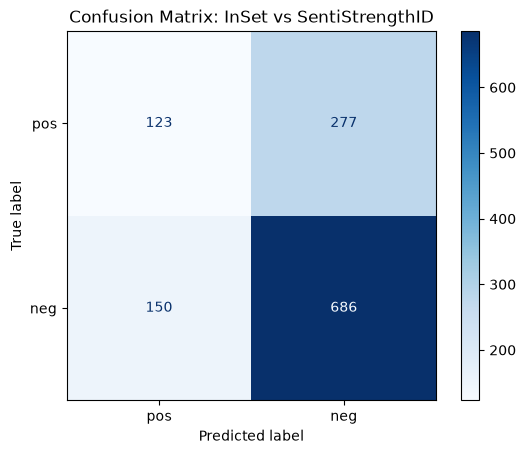

In [23]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y1, y2, labels=['pos', 'neg'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['pos', 'neg'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix: InSet vs SentiStrengthID')
plt.show()

In [24]:
# Classification report
from sklearn.metrics import classification_report

print(classification_report(y1, y2, labels=['pos', 'neg']))

              precision    recall  f1-score   support

         pos       0.45      0.31      0.37       400
         neg       0.71      0.82      0.76       836

    accuracy                           0.65      1236
   macro avg       0.58      0.56      0.56      1236
weighted avg       0.63      0.65      0.63      1236

